In [1]:
import sys
import os
from glob import glob
import pandas as pd
import spatialproteomics
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import tifffile
import scanpy as sc
import anndata as ad
import warnings
warnings.filterwarnings("ignore")

import gc
gc.collect() 

20

In [2]:
dat = { f.split('/')[-1].split('.')[0]: xr.open_zarr(f) for f in glob("./zarr/*.zarr") }

In [3]:
channels=list(dat['test_run24_2'].channels.to_dataframe().index)

In [4]:
channels

['DAPI',
 '050 CD138',
 '011 SMA',
 '013 Ki-67',
 '121 c-kit',
 '009 CD11b',
 '016 Nestin',
 '055 CD36',
 '052 CD16',
 '006 Collagen IV human',
 '024 CD20',
 '079 S100B',
 '026 CD68',
 '025 CD34 human',
 '074 PF4',
 '010 CD14',
 '007 CD4',
 '127 CD61',
 '150 VCAM-1',
 '023 CD11c',
 '072 Perilipin',
 '123 IDO1',
 '015 Vimentin',
 '132 Interferon gamma',
 '008 CD3e',
 '062 CXCL13',
 '004 Gycophorin A',
 '125 MCT',
 '122 CD38',
 '051 CD146',
 '077 S100A4',
 '019 Collagen 1',
 '128 Na/-K/ATPase',
 '126 S100A8 9',
 '084 CD56 (NCam1)',
 '071 Podoplanin',
 '006 HLA-DR CD74',
 '103 CXCL12',
 '124 TGFB1',
 '001 CD31',
 '129 SPP1',
 '151 ISG15',
 '152 MGP',
 '153 PDE5a']

In [5]:
#list(dat.keys())

In [6]:
runs=['21', '22', '23', '24']
condition_vecs={'21':['d180', 'd0', 'd0', 'd60', 'd180'],
                   '22':['d365', 'd0', 'd60'],
                   '23':['d0', 'd365', 'd60', 'd100'],
                   '24':['d0', 'd270', 'd0', 'd365', 'd180']}

In [7]:
#filt_quant=0.8
filt_quant=0.9

In [8]:
#i=0
for run in runs:
    for i in range(len(condition_vecs[run])):
        
        idx=[str(n)+'_run'+run+'_'+condition_vecs[run][i]+'_'+str(i+1) for n in pd.DataFrame(dat['test_run'+run+'_'+str(i+1)]._obs).index]
        int_prots=pd.DataFrame(dat['test_run'+run+'_'+str(i+1)]._intensity.data, columns=channels, index=idx)
        int_prots=int_prots[['072 Perilipin', '127 CD61', '125 MCT', '153 PDE5a']]
        dat['test_run'+run+'_'+str(i+1)] = dat['test_run'+run+'_'+str(i+1)].pp.add_obs_from_dataframe(int_prots)
    
        CTs=pd.DataFrame('Cell', index=idx, columns=['label'])
        #CTs['label'][(int_prots['072 Perilipin']>np.quantile(int_prots['072 Perilipin'], filt_quant))&(int_prots['127 CD61']>np.quantile(int_prots['127 CD61'], filt_quant))]='Removed'
        CTs['label'][(int_prots['125 MCT']>np.quantile(int_prots['125 MCT'], filt_quant))]='Removed'
        CTs['cell']=pd.DataFrame(dat['test_run'+run+'_'+str(i+1)]._obs).index
        CTs['label']=CTs['label'].astype(str)

        dat['test_run'+run+'_'+str(i+1)] = dat['test_run'+run+'_'+str(i+1)].pp.drop_layers('_la_properties')
        dat['test_run'+run+'_'+str(i+1)] = dat['test_run'+run+'_'+str(i+1)].la.add_labels_from_dataframe(CTs)

Removing labels from observations. If you want to keep the labels in the obs layer, set drop_obs=False.
Removing labels from observations. If you want to keep the labels in the obs layer, set drop_obs=False.
Removing labels from observations. If you want to keep the labels in the obs layer, set drop_obs=False.
Removing labels from observations. If you want to keep the labels in the obs layer, set drop_obs=False.
Removing labels from observations. If you want to keep the labels in the obs layer, set drop_obs=False.
Removing labels from observations. If you want to keep the labels in the obs layer, set drop_obs=False.
Removing labels from observations. If you want to keep the labels in the obs layer, set drop_obs=False.
Removing labels from observations. If you want to keep the labels in the obs layer, set drop_obs=False.
Removing labels from observations. If you want to keep the labels in the obs layer, set drop_obs=False.
Removing labels from observations. If you want to keep the label

In [9]:
## colors
#import seaborn as sns
#clist=sns.color_palette("tab10").as_hex()
#clist=['#D3D3D3', '#808080', '#4CBB17']

In [10]:
# A clean way to update a specific label by name:
#for smpl in range(0,3):
for run in runs:
    for i in range(len(condition_vecs[run])):
        #lab_props=pd.DataFrame(dat['test_run'+run+'_'+str(i+1)]._la_properties, columns=['color', 'label'])
        #for i in range(len(lab_props['label'])):
            #label_to_change = lab_props['label'][i]
            #new_color = clist[i]
        label_to_change = "Cell"
        new_color = '#D3D3D3' # lightgray
            
            # Find the row index where the second column matches your label
            #mask = dat['test_run'+run+'_'+str(i+1)]._la_properties[:, 1] == label_to_change
            #dat['test_run'+run+'_'+str(i+1)]._la_properties[mask, 0] = new_color
        mask = dat['test_run'+run+'_'+str(i+1)]._la_properties[:, 1] == label_to_change
        dat['test_run'+run+'_'+str(i+1)]._la_properties[mask, 0] = new_color
        
        label_to_change = "Removed"
        new_color = "red" # Red
            
        # Find the row index where the second column matches your label
        mask = dat['test_run'+run+'_'+str(i+1)]._la_properties[:, 1] == label_to_change
        dat['test_run'+run+'_'+str(i+1)]._la_properties[mask, 0] = new_color

In [11]:
list(dat.keys())

['test_run24_2',
 'test_run21_2',
 'test_run22_1',
 'test_run23_1',
 'test_run24_5',
 'test_run22_2',
 'test_run23_3',
 'test_run23_2',
 'test_run23_4',
 'test_run21_5',
 'test_run21_1',
 'test_run21_4',
 'test_run22_3',
 'test_run24_1',
 'test_run24_4',
 'test_run24_3',
 'test_run21_3']

In [12]:
#_=dat[list(dat.keys())[0]].pp[2300:7200, 2000:6000].pl.render_obs("127 CD61").pl.imshow(legend_obs=True, ax=plt.gca())
#_=dat[list(dat.keys())[1]].pp[4000:9000, 6500:11000].pl.render_obs("127 CD61").pl.imshow(legend_obs=True, ax=plt.gca())
#_=dat[list(dat.keys())[2]].pp[2300:7200, 4000:8000].pl.render_obs("127 CD61").pl.imshow(legend_obs=True, ax=plt.gca())
#_=dat[list(dat.keys())[3]].pp[2300:7200, 2000:6000].pl.render_obs("127 CD61").pl.imshow(legend_obs=True, ax=plt.gca())
#_=dat[list(dat.keys())[4]].pp[2300:7200, 2000:6000].pl.render_obs("127 CD61").pl.imshow(legend_obs=True, ax=plt.gca())
#_=dat[list(dat.keys())[5]].pp[7000:11000, 13000:17000].pl.render_obs("127 CD61").pl.imshow(legend_obs=True, ax=plt.gca())
#_=dat[list(dat.keys())[6]].pp[3500:8000, 2000:6000].pl.render_obs("127 CD61").pl.imshow(legend_obs=True, ax=plt.gca())
#_=dat[list(dat.keys())[7]].pp[6000:10000, 8000:12000].pl.render_obs("127 CD61").pl.imshow(legend_obs=True, ax=plt.gca())
#_=dat[list(dat.keys())[8]].pp[2300:7200, 4000:8000].pl.render_obs("127 CD61").pl.imshow(legend_obs=True, ax=plt.gca())
#_=dat[list(dat.keys())[9]].pp[2300:7200, 2000:6000].pl.render_obs("127 CD61").pl.imshow(legend_obs=True, ax=plt.gca())
#_=dat[list(dat.keys())[10]].pp[10000:14000, 9000:13000].pl.render_obs("127 CD61").pl.imshow(legend_obs=True, ax=plt.gca())
#_=dat[list(dat.keys())[11]].pp[2300:7200, 2000:6000].pl.render_obs("127 CD61").pl.imshow(legend_obs=True, ax=plt.gca())
#_=dat[list(dat.keys())[12]].pp[3000:8000, 3000:7000].pl.render_obs("127 CD61").pl.imshow(legend_obs=True, ax=plt.gca())
#_=dat[list(dat.keys())[13]].pp[2300:7200, 2000:6000].pl.render_obs("127 CD61").pl.imshow(legend_obs=True, ax=plt.gca())
#_=dat[list(dat.keys())[14]].pp[2300:7200, 1000:5000].pl.render_obs("127 CD61").pl.imshow(legend_obs=True, ax=plt.gca())
#_=dat[list(dat.keys())[15]].pp[2300:7200, 2000:6000].pl.render_obs("127 CD61").pl.imshow(legend_obs=True, ax=plt.gca())
#_=dat[list(dat.keys())[16]].pp[4000:8000, 2500:7000].pl.render_obs("127 CD61").pl.imshow(legend_obs=True, ax=plt.gca())
keys=list(dat.keys())
values=[[2300,7200, 2000,6000],[4000,9000, 6500,11000], [2300,7200, 4000,8000], [2300,7200, 2000,6000], [2300,7200, 2000,6000], [7000,11000, 13000,17000], 
        [3500,8000, 2000,6000], [6000,10000, 8000,12000], [2300,7200, 4000,8000], [2300,7200, 2000,6000], [10000,14000, 9000,13000], [2300,7200, 2000,6000],
        [3000,8000, 3000,7000], [2300,7200, 2000,6000], [2300,7200, 1000,5000], [2300,7200, 2000,6000], [4000,8000, 2500,7000]]

coords_dict=dictionary = dict(zip(keys, values))

In [13]:
#for smpl in list(dat.keys()):
#    fig, ax = plt.subplots(1, 1, figsize=(8, 8))
#    _=dat[smpl].pp[2300:7200, 2000:6000].pl.render_obs("127 CD61").pl.imshow(legend_obs=True, ax=ax)
#    plt.show()

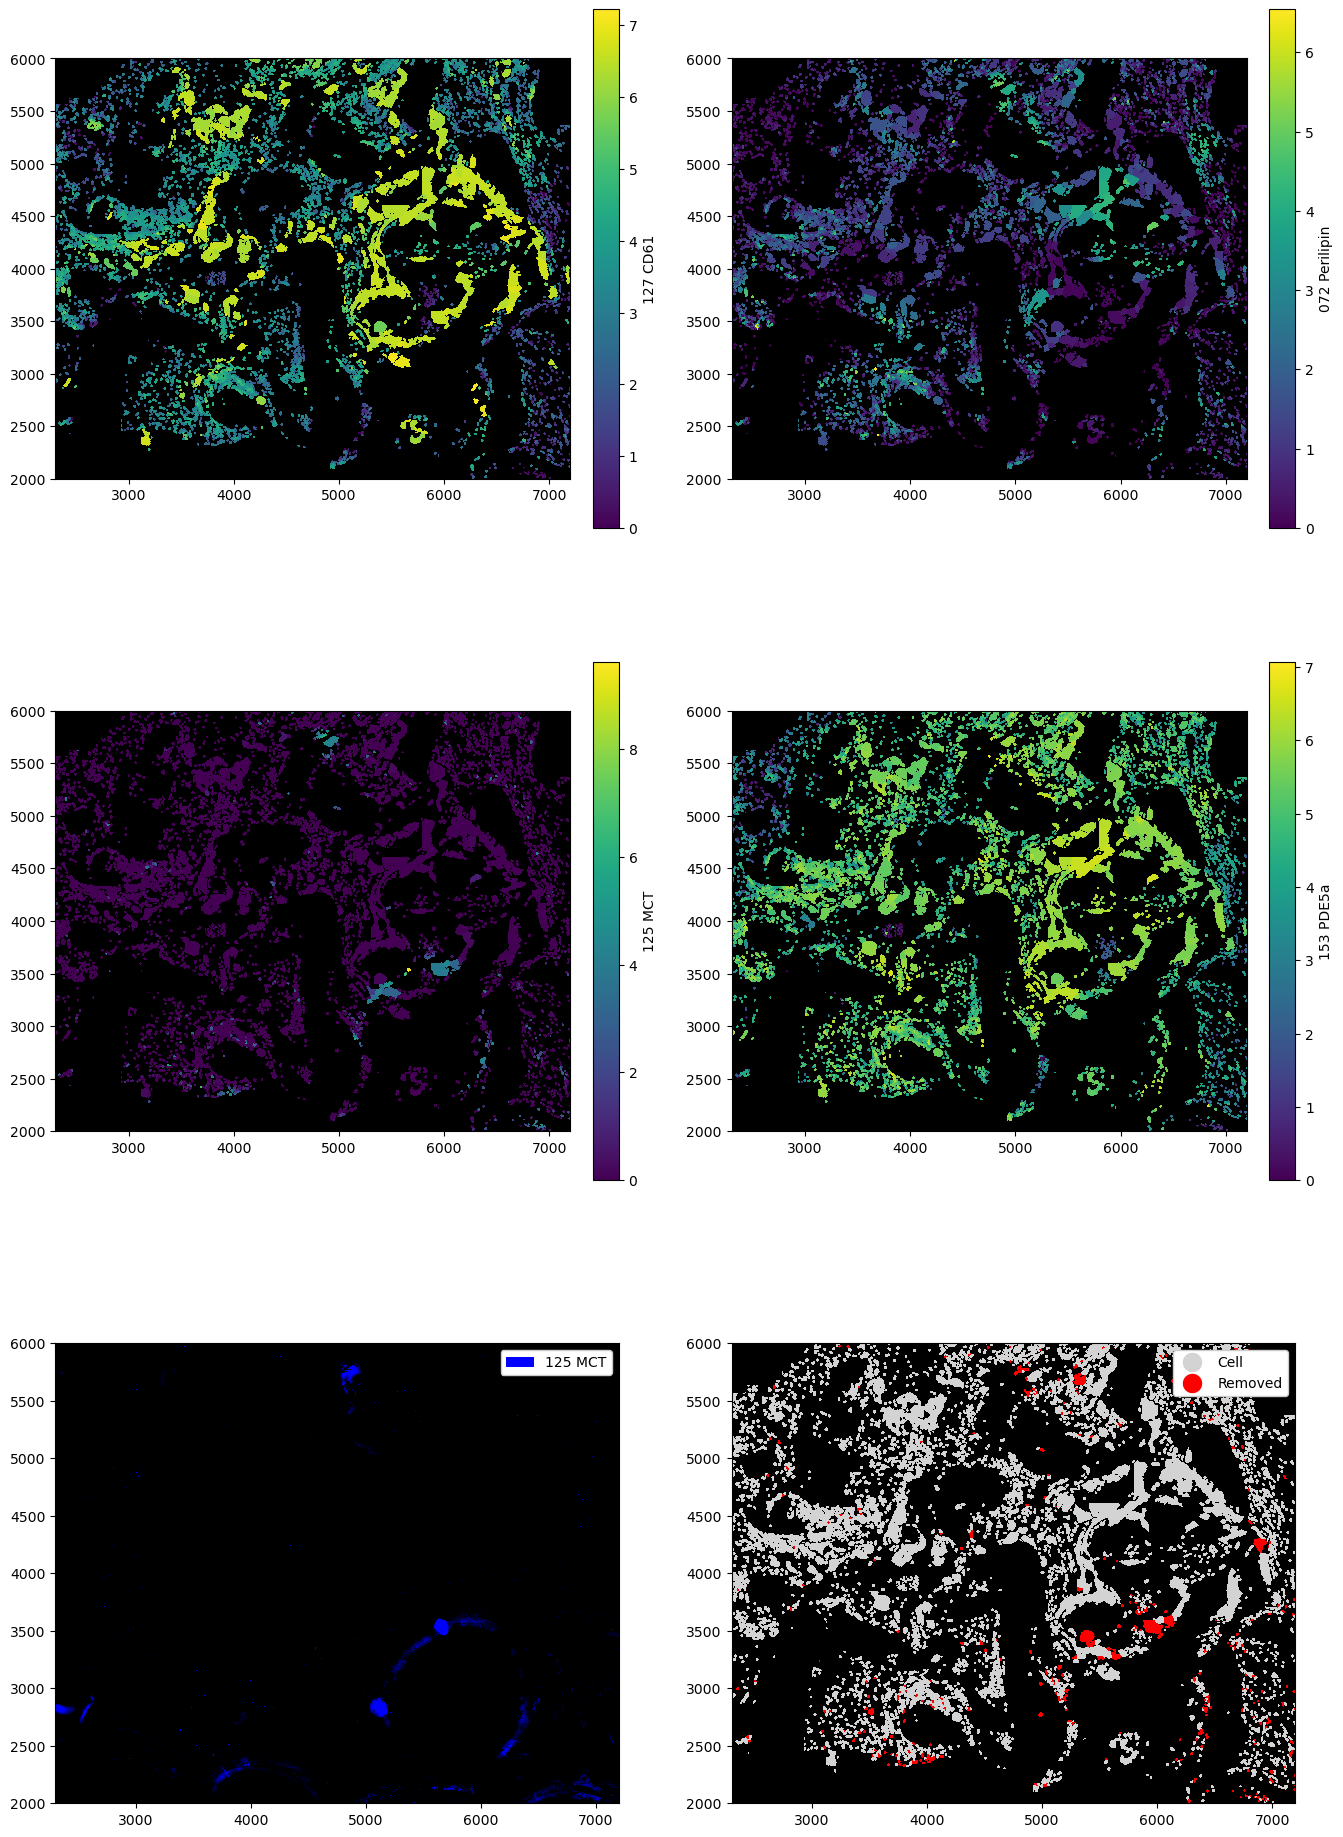

In [14]:
fig, ax = plt.subplots(3, 2, figsize=(16, 24))
_ = dat['test_run24_2'].pp[2300:7200, 2000:6000].pl.render_obs("127 CD61").pl.imshow(legend_obs=True, ax=ax[0][0])
_ = dat['test_run24_2'].pp[2300:7200, 2000:6000].pl.render_obs("072 Perilipin").pl.imshow(legend_obs=True, ax=ax[0][1])
_ = dat['test_run24_2'].pp[2300:7200, 2000:6000].pl.render_obs("125 MCT").pl.imshow(legend_obs=True, ax=ax[1][0])
_ = dat['test_run24_2'].pp[2300:7200, 2000:6000].pl.render_obs("153 PDE5a").pl.imshow(legend_obs=True, ax=ax[1][1])

#_ = dat['test_run24_2'].pp[["072 Perilipin", "127 CD61"], 2300:7200, 2000:6000].pp.threshold(quantile=[filt_quant, filt_quant]).pl.colorize(["#0000FF", "#00FF00"]).pl.show(ax=ax[2][0])
_ = dat['test_run24_2'].pp[["125 MCT"], 2300:7200, 2000:6000].pp.threshold(quantile=[filt_quant]).pl.colorize(["#0000FF"]).pl.show(ax=ax[2][0])
#_=ds_small.pl.colorize(["#d62728", "#8c564b"]).pl.show(ax=ax[0])
_ = (
    dat['test_run24_2'].pp[2300:7200, 2000:6000]
    .la["Cell", "Removed"]
    #.la.set_label_colors(["Cell", "Removed"], ["#0000FF", "#00FF00"])
    #.pl.show(render_image=False, render_segmentation=True, render_labels=True, ax=ax[1][1])
    .pl.show(render_image=False, render_labels=True, ax=ax[2][1])
)

In [15]:
#fig.savefig('./visual_output/filtering_mks_test_run24_2.png', dpi=1200)
fig.savefig('./visual_output/filtering_MCT_test_run24_2.png', dpi=1200)

In [16]:
import matplotlib
matplotlib.use('Agg')

In [17]:
for smpl in list(dat.keys()):
    fig, ax = plt.subplots(3, 2, figsize=(16, 24))
    _ = dat[smpl].pp[coords_dict[smpl][0]:coords_dict[smpl][1], coords_dict[smpl][2]:coords_dict[smpl][3]].pl.render_obs("127 CD61").pl.imshow(legend_obs=True, ax=ax[0][0])
    _ = dat[smpl].pp[coords_dict[smpl][0]:coords_dict[smpl][1], coords_dict[smpl][2]:coords_dict[smpl][3]].pl.render_obs("072 Perilipin").pl.imshow(legend_obs=True, ax=ax[0][1])
    _ = dat[smpl].pp[coords_dict[smpl][0]:coords_dict[smpl][1], coords_dict[smpl][2]:coords_dict[smpl][3]].pl.render_obs("125 MCT").pl.imshow(legend_obs=True, ax=ax[1][0])
    _ = dat[smpl].pp[coords_dict[smpl][0]:coords_dict[smpl][1], coords_dict[smpl][2]:coords_dict[smpl][3]].pl.render_obs("153 PDE5a").pl.imshow(legend_obs=True, ax=ax[1][1])
    
    #_ = dat[smpl].pp[["072 Perilipin", "127 CD61"], 2300:7200, 2000:6000].pp.threshold(quantile=[filt_quant, filt_quant]).pl.colorize(["#0000FF", "#00FF00"]).pl.show(ax=ax[2][0])
    _ = dat[smpl].pp[["125 MCT"], coords_dict[smpl][0]:coords_dict[smpl][1], coords_dict[smpl][2]:coords_dict[smpl][3]].pp.threshold(quantile=[filt_quant]).pl.colorize(["#0000FF"]).pl.show(ax=ax[2][0])

    _ = (
        dat[smpl].pp[coords_dict[smpl][0]:coords_dict[smpl][1], coords_dict[smpl][2]:coords_dict[smpl][3]]
        .la["Cell", "Removed"]
        #.la.set_label_colors(["Cell", "Removed"], ["#0000FF", "#00FF00"])
        #.pl.show(render_image=False, render_segmentation=True, render_labels=True, ax=ax[1][1])
        .pl.show(render_image=False, render_labels=True, ax=ax[2][1])
    )
    #fig.savefig('./visual_output/filtering_mks_'+smpl+'.png', dpi=1200)
    fig.savefig('./visual_output/filtering_MCT_q'+str(filt_quant)+'_'+smpl+'.png', dpi=1200)